In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find project root
PROJECT_ROOT = Path.cwd()

# If notebook is launched from notebooks/, move up one level
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TGSRTC_DIR = PROJECT_ROOT / "data" / "raw" / "tgsrtc_gtfs_jun2026"

print("Project:", PROJECT_ROOT)
print("TGSRTC:", TGSRTC_DIR)
print("Exists:", TGSRTC_DIR.exists())

Project: /Users/sid/Documents/coding/datajam-cyberabad
TGSRTC: /Users/sid/Documents/coding/datajam-cyberabad/data/raw/tgsrtc_gtfs_jun2026
Exists: True


In [3]:
agency = pd.read_csv(TGSRTC_DIR / "agency.txt")
calendar = pd.read_csv(TGSRTC_DIR / "calendar.txt")
feed_info = pd.read_csv(TGSRTC_DIR / "feed_info.txt")
routes = pd.read_csv(TGSRTC_DIR / "routes.txt")
stop_times = pd.read_csv(TGSRTC_DIR / "stop_times.txt")
stops = pd.read_csv(TGSRTC_DIR / "stops.txt")
trips = pd.read_csv(TGSRTC_DIR / "trips.txt")

print("TGSRTC GTFS loaded successfully.")

TGSRTC GTFS loaded successfully.


In [ ]:
from pathlib import Path
import pandas as pd

# Project paths
PROJECT_ROOT = Path.cwd().parent
HMRL_DIR = PROJECT_ROOT / "Telangana_opendata_gtfs_hmrl_02_September_2026"

# Load GTFS files
agency = pd.read_csv(HMRL_DIR / "agency.txt")
calendar = pd.read_csv(HMRL_DIR / "calendar.txt")
fare_attributes = pd.read_csv(HMRL_DIR / "fare_attributes.txt")
fare_rules = pd.read_csv(HMRL_DIR / "fare_rules.txt")
feed_info = pd.read_csv(HMRL_DIR / "feed_info.txt")
routes = pd.read_csv(HMRL_DIR / "routes.txt")
shapes = pd.read_csv(HMRL_DIR / "shapes.txt")
stop_times = pd.read_csv(HMRL_DIR / "stop_times.txt")
stops = pd.read_csv(HMRL_DIR / "stops.txt")
trips = pd.read_csv(HMRL_DIR / "trips.txt")

print("HMRL GTFS loaded successfully.")

HMRL GTFS loaded successfully.


In [4]:
overview = {
    "Routes": len(routes),
    "Stops": len(stops),
    "Trips": len(trips),
    "Stop-time records": len(stop_times),
}

pd.Series(overview)

Routes                 1501
Stops                  4709
Trips                 31765
Stop-time records    809218
dtype: int64

In [ ]:
for name, df in {
    "agency": agency,
    "calendar": calendar,
    "routes": routes,
    "trips": trips,
    "stops": stops,
    "stop_times": stop_times,
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

In [6]:
for name, df in {
    "agency": agency,
    "calendar": calendar,
    "routes": routes,
    "trips": trips,
    "stops": stops,
    "stop_times": stop_times,
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))


AGENCY
Shape: (1, 5)
Columns: ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang']

CALENDAR
Shape: (1, 10)
Columns: ['service_id', 'start_date', 'end_date', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

ROUTES
Shape: (1501, 4)
Columns: ['route_id', 'route_short_name', 'agency_id', 'route_type']

TRIPS
Shape: (31765, 5)
Columns: ['route_id', 'trip_id', 'service_id', 'direction_id', 'trip_short_name']

STOPS
Shape: (4709, 6)
Columns: ['stop_id', 'stop_name', 'zone_id', 'stop_lat', 'stop_lon', 'stop_desc']

STOP_TIMES
Shape: (809218, 6)
Columns: ['trip_id', 'stop_sequence', 'stop_id', 'departure_time', 'arrival_time', 'timepoint']


In [7]:
display(agency)
display(feed_info)
display(calendar)

,agency_id,agency_name,agency_url,agency_timezone,agency_lang
0,TGSRTC,Telangana State Road Transport Corporation,https://tgsrtc.telangana.gov.in/,Asia/Kolkata,en


,feed_publisher_name,feed_publisher_url,feed_contact_email,feed_contact_url,feed_lang,feed_start_date,feed_end_date,feed_version
0,Open Data Telangana,https://data.telangana.gov.in,opendata@telangana.gov.in,https://data.telangana.gov.in,en,20260601,20310601,20260601


,service_id,start_date,end_date,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,MTWTFSS,20260601,20310601,1,1,1,1,1,1,1


In [8]:
routes["route_type"].value_counts()

route_type
3    1501
Name: count, dtype: int64

In [9]:
trips_per_route = (
    trips
    .groupby("route_id")
    .size()
    .sort_values(ascending=False)
)

trips_per_route.describe()

count    1501.000000
mean       21.162558
std        54.855983
min         1.000000
25%         1.000000
50%         4.000000
75%        13.000000
max       902.000000
dtype: float64

In [10]:
route_stop_counts = (
    stop_times
    .merge(
        trips[["trip_id", "route_id"]],
        on="trip_id",
        how="left"
    )
    .groupby("route_id")["stop_id"]
    .nunique()
    .sort_values(ascending=False)
)

route_stop_counts.describe()

count    1501.000000
mean       40.260493
std        25.722197
min         2.000000
25%        21.000000
50%        35.000000
75%        56.000000
max       155.000000
Name: stop_id, dtype: float64

In [11]:
route_stop_counts.head(20)

route_id
300         155
218C        144
567         143
218H        132
218         130
250C/219    127
113K/L      125
218V        125
219/229     125
219/18C     123
555V/D      123
217H        121
532         120
17H/219I    118
218L        117
217C        117
300/217     115
17H/219     115
9X/272G     113
217         112
Name: stop_id, dtype: int64

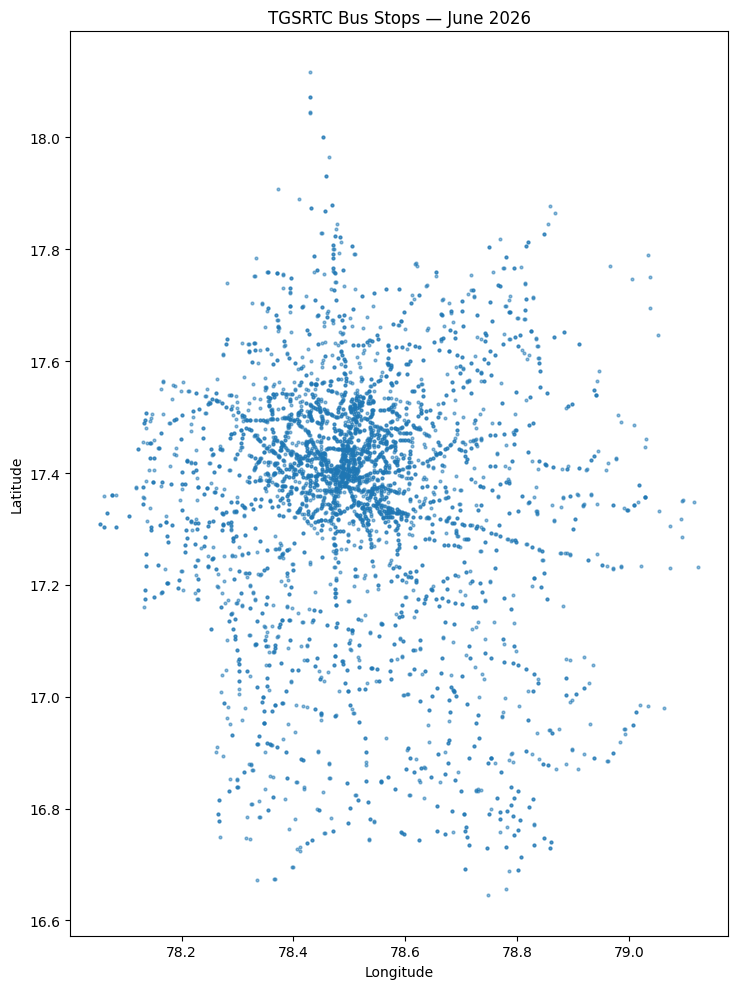

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    stops["stop_lon"],
    stops["stop_lat"],
    s=4,
    alpha=0.5
)

ax.set_title("TGSRTC Bus Stops — June 2026")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# TGSRTC GTFS — June 2026
# 1. Setup and Data Loading
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Find project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Dataset path
TGSRTC_DIR = PROJECT_ROOT / "data" / "raw" / "tgsrtc_gtfs_jun2026"

print("Project root:", PROJECT_ROOT)
print("TGSRTC dataset:", TGSRTC_DIR)
print("Dataset exists:", TGSRTC_DIR.exists())

Project root: /Users/sid/Documents/coding/datajam-cyberabad
TGSRTC dataset: /Users/sid/Documents/coding/datajam-cyberabad/data/raw/tgsrtc_gtfs_jun2026
Dataset exists: True


In [15]:
# ============================================================
# 1.1 Load GTFS Tables
# ============================================================

agency = pd.read_csv(TGSRTC_DIR / "agency.txt")
calendar = pd.read_csv(TGSRTC_DIR / "calendar.txt")
feed_info = pd.read_csv(TGSRTC_DIR / "feed_info.txt")
routes = pd.read_csv(TGSRTC_DIR / "routes.txt")
stop_times = pd.read_csv(TGSRTC_DIR / "stop_times.txt")
stops = pd.read_csv(TGSRTC_DIR / "stops.txt")
trips = pd.read_csv(TGSRTC_DIR / "trips.txt")

print("TGSRTC GTFS loaded successfully.")

TGSRTC GTFS loaded successfully.


In [16]:
# ============================================================
# 2. Bus Stop Dataset
# ============================================================

bus = stops[
    [
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
        "zone_id",
        "stop_desc"
    ]
].copy()

bus = bus.rename(columns={
    "stop_id": "bus_id",
    "stop_name": "bus_name",
    "stop_lat": "lat",
    "stop_lon": "lon"
})

print(f"TGSRTC bus stops: {len(bus):,}")

bus.head()

TGSRTC bus stops: 4,709


,bus_id,bus_name,lat,lon,zone_id,stop_desc
0,RgqMpbyP,Charminar,17.358678,78.474028,Charminar,CHARMINAR
1,ZesADyKB,Shahalibanda,17.354750,78.473024,Shahalibanda,SHALIBANDA twd Charminar
2,CSCQevOc,Kilwat,17.360127,78.471375,Kilwat,KILWATH twd Afzalgunj
3,RcYax5EA,Moosabowli,17.364275,78.466668,Moosabowli,MOOSABOWLY twd CBS
4,UoDW1Rgg,City College,17.367453,78.468290,City College,CITY College twd Afzalgunj


In [17]:
# ============================================================
# 2.1 Bus Stop Data Quality Check
# ============================================================

print("Unique bus stops:", bus["bus_id"].nunique())
print("Missing latitude:", bus["lat"].isna().sum())
print("Missing longitude:", bus["lon"].isna().sum())
print("Duplicate bus IDs:", bus["bus_id"].duplicated().sum())

Unique bus stops: 4709
Missing latitude: 0
Missing longitude: 0
Duplicate bus IDs: 0


In [18]:
# ============================================================
# 3.1 Route Types
# ============================================================

route_type_counts = routes["route_type"].value_counts().sort_index()

route_type_counts

route_type
3    1501
Name: count, dtype: int64

In [19]:
# ============================================================
# 3.2 Scheduled Trips by Route
# ============================================================

trips_per_route = (
    trips
    .groupby("route_id")
    .agg(
        scheduled_trips=("trip_id", "nunique")
    )
    .reset_index()
    .sort_values("scheduled_trips", ascending=False)
)

trips_per_route.head(20)

,route_id,scheduled_trips
830,300,902
454,219,686
1404,8A,556
782,290U,437
719,279,408
64,10H,392
94,113M,314
1135,49M,304
1076,47L,297
118,117,292


In [20]:
# ============================================================
# 3.3 Distribution of Scheduled Trips per Route
# ============================================================

trips_per_route["scheduled_trips"].describe()

count    1501.000000
mean       21.162558
std        54.855983
min         1.000000
25%         1.000000
50%         4.000000
75%        13.000000
max       902.000000
Name: scheduled_trips, dtype: float64

In [21]:
# ============================================================
# 3.4 Highest-Service TGSRTC Routes
# ============================================================

top_routes = (
    trips
    .groupby("route_id")
    .agg(
        scheduled_trips=("trip_id", "nunique")
    )
    .reset_index()
    .merge(
        routes,
        on="route_id",
        how="left"
    )
    .sort_values("scheduled_trips", ascending=False)
)

top_routes[
    [
        "route_id",
        "route_short_name",
        "scheduled_trips"
    ]
].head(20)

,route_id,route_short_name,scheduled_trips
830,300,300,902
454,219,219,686
1404,8A,8A,556
782,290U,290U,437
719,279,279,408
64,10H,10H,392
94,113M,113M,314
1135,49M,49M,304
1076,47L,47L,297
118,117,117,292


In [22]:
# ============================================================
# 3.5 Lowest-Service Routes
# ============================================================

top_routes[
    [
        "route_id",
        "route_short_name",
        "scheduled_trips"
    ]
].sort_values("scheduled_trips").head(20)

,route_id,route_short_name,scheduled_trips
1500,WONDERLA,WONDERLA,1
324,1Z/95M,1Z/95M,1
1352,72H/204,72H/204,1
337,201P,201P,1
1381,7Z/536,7Z/536,1
1385,8/253M,8/253M,1
166,16A/20,16A/20,1
198,171D/B,171D/B,1
167,16A/20P,16A/20P,1
170,16A/290,16A/290,1


In [23]:
# ============================================================
# 4.1 Build Stop-Level Service Dataset
# ============================================================

# Connect each stop-time record to its route through trip_id
stop_service = (
    stop_times[
        ["trip_id", "stop_id"]
    ]
    .merge(
        trips[
            ["trip_id", "route_id", "direction_id"]
        ],
        on="trip_id",
        how="left"
    )
)

print(f"Stop-time records: {len(stop_service):,}")
print(f"Unique stops: {stop_service['stop_id'].nunique():,}")
print(f"Unique routes: {stop_service['route_id'].nunique():,}")

Stop-time records: 809,218
Unique stops: 4,709
Unique routes: 1,501


In [24]:
# ============================================================
# 4.2 Calculate Service by Bus Stop
# ============================================================

stop_service_summary = (
    stop_service
    .groupby("stop_id")
    .agg(
        routes_serving=("route_id", "nunique"),
        scheduled_trips=("trip_id", "nunique")
    )
    .reset_index()
    .merge(
        bus[
            ["bus_id", "bus_name", "lat", "lon"]
        ],
        left_on="stop_id",
        right_on="bus_id",
        how="left"
    )
)

stop_service_summary.head()

,stop_id,routes_serving,scheduled_trips,bus_id,bus_name,lat,lon
0,01tUbAym,3,151,01tUbAym,Ambedkar Nagar-Nagaram,17.479845,78.619972
1,02K84jHY,11,25,02K84jHY,Dabilpur Railway Station,17.674000,78.470000
2,02VFviui,2,4,02VFviui,Kothur Thanda,17.138822,78.295795
3,02vWmciA,3,77,02vWmciA,Rajeev Gandhi Nagar 2-,17.535946,78.364862
4,03dKkFHP,9,82,03dKkFHP,Kethireddy Pally Cross Road,17.310260,78.229018


In [25]:
# ============================================================
# 4.3 Distribution of Routes and Scheduled Trips per Stop
# ============================================================

stop_service_summary[
    ["routes_serving", "scheduled_trips"]
].describe()

,routes_serving,scheduled_trips
count,4709.000000,4709.000000
mean,12.833086,171.818220
std,20.948935,341.075788
min,1.000000,1.000000
25%,2.000000,5.000000
50%,4.000000,29.000000
75%,14.000000,173.000000
max,351.000000,8223.000000


In [26]:
# ============================================================
# 4.4 Highest-Service Bus Stops
# ============================================================

stop_service_summary.sort_values(
    "scheduled_trips",
    ascending=False
)[
    [
        "bus_id",
        "bus_name",
        "routes_serving",
        "scheduled_trips"
    ]
].head(20)

,bus_id,bus_name,routes_serving,scheduled_trips
4283,u3bvsFOc,Secunderabad,351,8223
1848,NUmq3A4e,Mehdipatnam,147,3059
3856,ok41NPb5,Patny,189,2958
3977,q9jjNdnh,Mehdipatnam,166,2788
2541,X0STVNy1,Patny,166,2786
1522,Ij8M0H6H,Afzalgunj,154,2782
1972,PRepdcnz,Ecil Cross Road,101,2669
3098,eNdxvjwG,Secunderabad,107,2644
2351,USn7tbeB,Lakdikapool,128,2443
1920,OkZJgFnt,Cbs,107,2421


In [27]:
# ============================================================
# 4.5 Service Concentration by Stop Name
# ============================================================

location_service_summary = (
    stop_service_summary
    .groupby("bus_name")
    .agg(
        gtfs_stop_ids=("bus_id", "nunique"),
        routes_serving=("routes_serving", "sum"),
        scheduled_trips=("scheduled_trips", "sum")
    )
    .reset_index()
    .sort_values(
        "scheduled_trips",
        ascending=False
    )
)

location_service_summary.head(20)

,bus_name,gtfs_stop_ids,routes_serving,scheduled_trips
2085,Secunderabad,7,627,13890
2351,Uppal Cross Road,6,329,6805
1716,Patny,5,442,6772
1417,Mehdipatnam,7,385,6395
16,Afzalgunj,5,361,6329
1247,Lb Nagar,6,373,5495
442,Chilkalguda,6,334,5206
1221,Lakdikapool,3,249,4765
374,Cbs,3,185,3953
60,Alugadda Bhavi,2,285,3942


In [28]:
# ============================================================
# 4.6 Highest-Service Named Bus Locations
# ============================================================

location_service_summary.head(20)

,bus_name,gtfs_stop_ids,routes_serving,scheduled_trips
2085,Secunderabad,7,627,13890
2351,Uppal Cross Road,6,329,6805
1716,Patny,5,442,6772
1417,Mehdipatnam,7,385,6395
16,Afzalgunj,5,361,6329
1247,Lb Nagar,6,373,5495
442,Chilkalguda,6,334,5206
1221,Lakdikapool,3,249,4765
374,Cbs,3,185,3953
60,Alugadda Bhavi,2,285,3942


In [30]:
# ============================================================
# 5.1 Prepare Metro and Bus Spatial Datasets
# ============================================================

# ------------------------------------------------------------
# Load HMRL station data
# ------------------------------------------------------------

HMRL_DIR = PROJECT_ROOT / "data" / "raw" / "hmrl_gtfs_sep2026"

hmrl_stops = pd.read_csv(HMRL_DIR / "stops.txt")

# Keep only parent stations
# location_type = 1 represents a station in the HMRL GTFS hierarchy
stations = hmrl_stops[
    hmrl_stops["location_type"] == 1
].copy()

metro = stations[
    ["stop_id", "stop_name", "stop_lat", "stop_lon"]
].copy()

metro = metro.rename(columns={
    "stop_id": "metro_id",
    "stop_name": "metro_name",
    "stop_lat": "lat",
    "stop_lon": "lon"
})

# ------------------------------------------------------------
# Prepare TGSRTC bus stops
# ------------------------------------------------------------

bus = stops[
    ["stop_id", "stop_name", "stop_lat", "stop_lon"]
].copy()

bus = bus.rename(columns={
    "stop_id": "bus_id",
    "stop_name": "bus_name",
    "stop_lat": "lat",
    "stop_lon": "lon"
})

print(f"HMRL Metro stations: {len(metro)}")
print(f"TGSRTC bus stops: {len(bus)}")

HMRL Metro stations: 57
TGSRTC bus stops: 4709


In [31]:
# ============================================================
# 5.2 Calculate Straight-Line Distance
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between geographic coordinates.

    Returns:
        Distance in metres.
    """
    
    earth_radius_m = 6_371_000

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * earth_radius_m * np.arcsin(np.sqrt(a))

In [32]:
# ============================================================
# 5.2 Calculate Straight-Line Distance
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between geographic coordinates.

    Returns:
        Distance in metres.
    """

    earth_radius_m = 6_371_000

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * earth_radius_m * np.arcsin(np.sqrt(a))

In [33]:
# ============================================================
# 5.3 Find Nearest TGSRTC Bus Stop
# ============================================================

nearest_bus = []

for _, metro_station in metro.iterrows():

    distances = haversine(
        metro_station["lat"],
        metro_station["lon"],
        bus["lat"].values,
        bus["lon"].values
    )

    nearest_index = np.argmin(distances)

    nearest_bus.append({
        "metro_id": metro_station["metro_id"],
        "metro_name": metro_station["metro_name"],
        "nearest_bus_id": bus.iloc[nearest_index]["bus_id"],
        "nearest_bus_name": bus.iloc[nearest_index]["bus_name"],
        "distance_m": distances[nearest_index]
    })

nearest_bus = pd.DataFrame(nearest_bus)

nearest_bus.sort_values("distance_m").head(10)

,metro_id,metro_name,nearest_bus_id,nearest_bus_name,distance_m
24,CHP,Chaitanyapuri,8ayey0mt,Kothapet Cross Road,11.394214
28,NAR,Narayanaguda,e5MGu6Vh,Ymca Narayanaguda,12.925751
16,NAM,Nampally,0Yr3hLAU,Nampally Railway Station,13.713906
56,RDG,Raidurg,Iu99uRam,Mind Space Centre,16.536712
9,SRN,S. R. Nagar,OCMZCOeo,Sr Nagar,17.319143
36,UPL,Uppal,bHfuhRVs,Uppal Cross Road,17.740045
8,ESI,ESI Hospital,C5vY3BnB,Esi Hospital,18.140498
18,OMC,Osmania Medical College,RhtakA8X,Putlibowli,18.224610
20,MKL,Malakpet,YWI4SVfO,Jail Garden,22.092637
35,NAG,Nagole,5YoLyTS1,Nagole Metro Station,25.875620


In [34]:
# ============================================================
# 5.4 Largest Nearest-Bus Distances
# ============================================================

nearest_bus.sort_values(
    "distance_m",
    ascending=False
).head(15)

,metro_id,metro_name,nearest_bus_id,nearest_bus_name,distance_m
47,BEG,Begumpet,KgDSpIOK,Rj College,319.551892
19,MGB,Mahatma Gandhi Bus Station,hQYYZWl5,Mgbs,268.382611
17,GAB,Gandhi Bhavan,nQotD9EE,Goshamahal,237.863346
22,MSB,Musarambagh,sZoLwKhA,Super Bazar Malakpet,235.542147
33,SCR,Secunderabad West,u3bvsFOc,Secunderabad,224.220425
37,STD,Stadium,SbVE8Ev9,Survey Of India,210.784238
0,MYP,Miyapur,5tRdKNc0,Miyapur Metro Station,206.707801
29,CDP,Chikkadpally,54FDshBp,Narayanaguda,198.403561
15,ASM,Assembly,48NXpBnL,Nampally Public Garden,190.552433
50,JR5,Road No 5 Jubilee Hills,qtEPoXCn,Indra Nagar-Jubilee Hills,180.973793


In [35]:
# ============================================================
# 6.1 Build Bus Stop Service Lookup
# ============================================================

bus_stop_service = (
    stop_service
    .groupby("stop_id")
    .agg(
        routes_serving=("route_id", "nunique"),
        scheduled_trips=("trip_id", "nunique")
    )
    .reset_index()
)

bus_stop_service.head()

,stop_id,routes_serving,scheduled_trips
0,01tUbAym,3,151
1,02K84jHY,11,25
2,02VFviui,2,4
3,02vWmciA,3,77
4,03dKkFHP,9,82


In [36]:
# ============================================================
# 6.2 Combine Bus Service and Spatial Data
# ============================================================

bus_enriched = bus.merge(
    bus_stop_service,
    left_on="bus_id",
    right_on="stop_id",
    how="left"
)

# Stops without scheduled service in the joined dataset
# are assigned zero for these analytical metrics.
bus_enriched["routes_serving"] = (
    bus_enriched["routes_serving"]
    .fillna(0)
    .astype(int)
)

bus_enriched["scheduled_trips"] = (
    bus_enriched["scheduled_trips"]
    .fillna(0)
    .astype(int)
)

bus_enriched.head()

,bus_id,bus_name,lat,lon,stop_id,routes_serving,scheduled_trips
0,RgqMpbyP,Charminar,17.358678,78.474028,RgqMpbyP,67,988
1,ZesADyKB,Shahalibanda,17.354750,78.473024,ZesADyKB,56,747
2,CSCQevOc,Kilwat,17.360127,78.471375,CSCQevOc,44,702
3,RcYax5EA,Moosabowli,17.364275,78.466668,RcYax5EA,36,690
4,UoDW1Rgg,City College,17.367453,78.468290,UoDW1Rgg,51,795


In [37]:
# ============================================================
# 6.3 Calculate Metro Catchment Service
# ============================================================

metro_connectivity = []

for _, metro_station in metro.iterrows():

    distances = haversine(
        metro_station["lat"],
        metro_station["lon"],
        bus_enriched["lat"].values,
        bus_enriched["lon"].values
    )

    for radius in [300, 500, 800]:

        nearby = bus_enriched.loc[distances <= radius].copy()

        metro_connectivity.append({
            "metro_id": metro_station["metro_id"],
            "metro_name": metro_station["metro_name"],
            "radius_m": radius,
            "bus_stops": nearby["bus_id"].nunique(),
            "routes": nearby["routes_serving"].sum(),
            "scheduled_trips": nearby["scheduled_trips"].sum()
        })

metro_connectivity = pd.DataFrame(metro_connectivity)

metro_connectivity.head(15)

,metro_id,metro_name,radius_m,bus_stops,routes,scheduled_trips
0,MYP,Miyapur,300,2,95,2083
1,MYP,Miyapur,500,2,95,2083
2,MYP,Miyapur,800,2,95,2083
3,JNT,JNTU College,300,4,131,2856
4,JNT,JNTU College,500,5,151,3415
5,JNT,JNTU College,800,12,396,8607
6,KPH,KPHB Colony,300,3,136,2715
7,KPH,KPHB Colony,500,4,146,2911
8,KPH,KPHB Colony,800,8,231,4598
9,KUK,Kukatpally,300,3,186,4015


In [38]:
# ============================================================
# 6.4 Calculate Distinct Routes Within Metro Catchments
# ============================================================

metro_connectivity = []

for _, metro_station in metro.iterrows():

    distances = haversine(
        metro_station["lat"],
        metro_station["lon"],
        bus_enriched["lat"].values,
        bus_enriched["lon"].values
    )

    for radius in [300, 500, 800]:

        nearby_stop_ids = bus_enriched.loc[
            distances <= radius,
            "bus_id"
        ]

        nearby_routes = stop_service.loc[
            stop_service["stop_id"].isin(nearby_stop_ids),
            "route_id"
        ].nunique()

        nearby_trips = stop_service.loc[
            stop_service["stop_id"].isin(nearby_stop_ids),
            "trip_id"
        ].nunique()

        metro_connectivity.append({
            "metro_id": metro_station["metro_id"],
            "metro_name": metro_station["metro_name"],
            "radius_m": radius,
            "bus_stops": len(nearby_stop_ids),
            "routes": nearby_routes,
            "scheduled_trips": nearby_trips
        })

metro_connectivity = pd.DataFrame(metro_connectivity)

metro_connectivity.head(15)

,metro_id,metro_name,radius_m,bus_stops,routes,scheduled_trips
0,MYP,Miyapur,300,2,64,2083
1,MYP,Miyapur,500,2,64,2083
2,MYP,Miyapur,800,2,64,2083
3,JNT,JNTU College,300,4,62,2270
4,JNT,JNTU College,500,5,62,2270
5,JNT,JNTU College,800,12,95,3172
6,KPH,KPHB Colony,300,3,88,2713
7,KPH,KPHB Colony,500,4,88,2717
8,KPH,KPHB Colony,800,8,112,3309
9,KUK,Kukatpally,300,3,98,3060


In [39]:
# ============================================================
# 6.5 Compare Metro Stations by Bus Connectivity
# ============================================================

metro_500m = (
    metro_connectivity[
        metro_connectivity["radius_m"] == 500
    ]
    .sort_values(
        "routes",
        ascending=False
    )
)

metro_500m.head(20)

,metro_id,metro_name,radius_m,bus_stops,routes,scheduled_trips
127,SEC_E,Secunderabad East,500,11,496,12726
100,SCR,Secunderabad West,500,2,354,8234
130,PRG,Parade Ground,500,16,345,8823
103,JBS,JBS Parade Ground,500,13,344,8797
82,SUB,Sultan Bazar,500,9,279,5716
61,MKL,Malakpet,500,9,259,4253
55,OMC,Osmania Medical College,500,10,234,6307
79,LBN,L. B. Nagar,500,4,213,3557
43,LKP,Lakdi-ka-pul,500,10,194,5215
70,DSN,Dilsukh Nagar,500,4,188,3453


In [40]:
# ============================================================
# 6.5 Compare Metro Stations by Bus Connectivity
# ============================================================

metro_500m = (
    metro_connectivity[
        metro_connectivity["radius_m"] == 500
    ]
    .sort_values(
        "routes",
        ascending=False
    )
)

metro_500m.head(20)

,metro_id,metro_name,radius_m,bus_stops,routes,scheduled_trips
127,SEC_E,Secunderabad East,500,11,496,12726
100,SCR,Secunderabad West,500,2,354,8234
130,PRG,Parade Ground,500,16,345,8823
103,JBS,JBS Parade Ground,500,13,344,8797
82,SUB,Sultan Bazar,500,9,279,5716
61,MKL,Malakpet,500,9,259,4253
55,OMC,Osmania Medical College,500,10,234,6307
79,LBN,L. B. Nagar,500,4,213,3557
43,LKP,Lakdi-ka-pul,500,10,194,5215
70,DSN,Dilsukh Nagar,500,4,188,3453


In [41]:
# ============================================================
# 6.6 Lowest Bus-Route Connectivity
# ============================================================

metro_500m.sort_values(
    "routes",
    ascending=True
).head(20)

,metro_id,metro_name,radius_m,bus_stops,routes,scheduled_trips
151,JR5,Road No 5 Jubilee Hills,500,5,8,480
148,YUG,Yusufguda,500,5,14,995
160,MAD,Madhapur,500,2,15,516
163,DGC,Durgam Cheruvu,500,4,18,968
157,PED,Peddamma Gudi,500,6,25,1019
154,JCP,Jubilee Hills Checkpost,500,5,26,938
169,RDG,Raidurg,500,6,34,577
166,HTC,HITEC City,500,6,47,1531
4,JNT,JNTU College,500,5,62,2270
97,GNH,Gandhi Hospital,500,4,62,1812


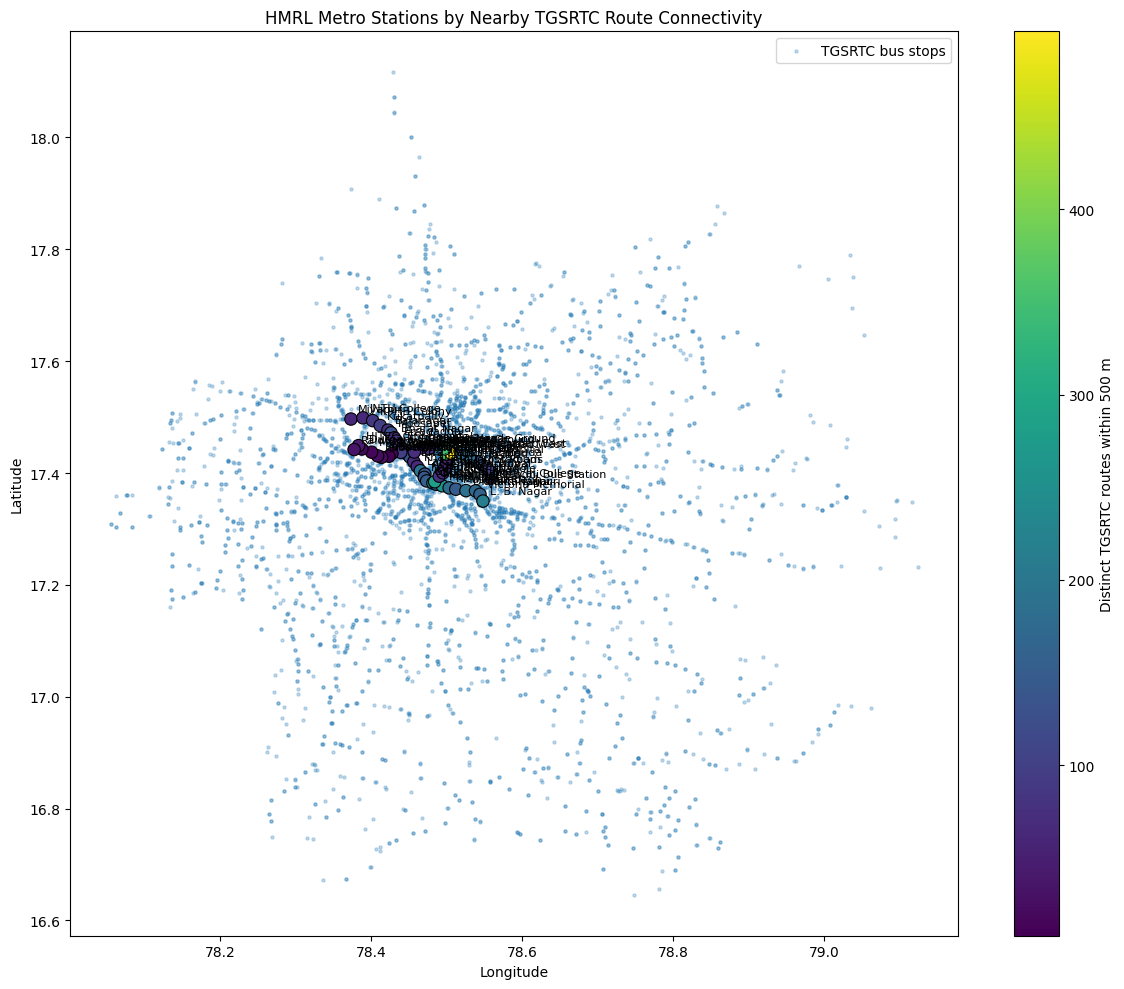

In [42]:
# ============================================================
# 7.1 Create Metro Connectivity Map
# ============================================================

# Get Metro station coordinates
metro_map = metro.merge(
    metro_500m[
        ["metro_id", "routes", "scheduled_trips", "bus_stops"]
    ],
    on="metro_id",
    how="left"
)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot TGSRTC bus stops
ax.scatter(
    bus["lon"],
    bus["lat"],
    s=5,
    alpha=0.25,
    label="TGSRTC bus stops"
)

# Plot Metro stations
scatter = ax.scatter(
    metro_map["lon"],
    metro_map["lat"],
    s=80,
    c=metro_map["routes"],
    edgecolors="black",
    linewidths=0.8
)

# Label Metro stations
for _, row in metro_map.iterrows():
    ax.annotate(
        row["metro_name"],
        (row["lon"], row["lat"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.colorbar(
    scatter,
    ax=ax,
    label="Distinct TGSRTC routes within 500 m"
)

ax.set_title(
    "HMRL Metro Stations by Nearby TGSRTC Route Connectivity"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# 7.2 Distribution of Metro–Bus Connectivity
# ============================================================

metro_500m["routes"].describe()

count     57.000000
mean     128.719298
std       95.358488
min        8.000000
25%       67.000000
50%       99.000000
75%      167.000000
max      496.000000
Name: routes, dtype: float64

In [44]:
# ============================================================
# 8.1 Prepare TGSRTC Departure Times
# ============================================================

# Convert GTFS departure times into seconds after midnight.
# GTFS times may exceed 24:00:00, so we parse them manually.

def gtfs_time_to_seconds(time_series):
    """
    Convert GTFS HH:MM:SS values into seconds.

    GTFS permits hours >= 24 for trips after midnight.
    """
    
    parts = time_series.str.split(":", expand=True)

    return (
        parts[0].astype(int) * 3600
        + parts[1].astype(int) * 60
        + parts[2].astype(int)
    )


stop_times_analysis = stop_times[
    ["trip_id", "stop_id", "departure_time"]
].copy()

stop_times_analysis["departure_seconds"] = (
    gtfs_time_to_seconds(
        stop_times_analysis["departure_time"]
    )
)

stop_times_analysis["departure_hour"] = (
    stop_times_analysis["departure_seconds"] // 3600
)

stop_times_analysis[
    ["trip_id", "stop_id", "departure_time", "departure_hour"]
].head()

,trip_id,stop_id,departure_time,departure_hour
0,863058,UBnpQRqJ,06:30:00,6
1,863058,GAstXCkZ,06:36:06,6
2,863058,CM04iqbe,06:42:55,6
3,863058,12LvRz4y,06:44:56,6
4,863058,P3E8zTnC,06:48:44,6


In [45]:
# ============================================================
# 8.2 Build Metro–Bus 500 m Catchment Relationships
# ============================================================

metro_bus_pairs = []

for _, metro_station in metro.iterrows():

    distances = haversine(
        metro_station["lat"],
        metro_station["lon"],
        bus["lat"].values,
        bus["lon"].values
    )

    nearby_bus = bus.loc[
        distances <= 500,
        ["bus_id"]
    ].copy()

    nearby_bus["metro_id"] = metro_station["metro_id"]
    nearby_bus["metro_name"] = metro_station["metro_name"]

    metro_bus_pairs.append(nearby_bus)

metro_bus_pairs = pd.concat(
    metro_bus_pairs,
    ignore_index=True
)

print(
    f"Metro–bus stop relationships: "
    f"{len(metro_bus_pairs):,}"
)

metro_bus_pairs.head()

Metro–bus stop relationships: 340


,bus_id,metro_id,metro_name
0,QaDZj4Nl,MYP,Miyapur
1,5tRdKNc0,MYP,Miyapur
2,lXQ2Ri6E,JNT,JNTU College
3,BcrTembT,JNT,JNTU College
4,NwqcEy3z,JNT,JNTU College


In [46]:
# ============================================================
# 8.3 Calculate Scheduled Bus Service by Hour
# ============================================================

metro_hourly_service = (
    metro_bus_pairs
    .merge(
        stop_times_analysis[
            [
                "stop_id",
                "trip_id",
                "departure_hour"
            ]
        ],
        left_on="bus_id",
        right_on="stop_id",
        how="inner"
    )
    .groupby(
        [
            "metro_id",
            "metro_name",
            "departure_hour"
        ]
    )
    .agg(
        scheduled_departures=("trip_id", "nunique")
    )
    .reset_index()
)

metro_hourly_service.head(20)

,metro_id,metro_name,departure_hour,scheduled_departures
0,AME,Ameerpet,4,8
1,AME,Ameerpet,5,49
2,AME,Ameerpet,6,121
3,AME,Ameerpet,7,150
4,AME,Ameerpet,8,151
5,AME,Ameerpet,9,189
6,AME,Ameerpet,10,160
7,AME,Ameerpet,11,152
8,AME,Ameerpet,12,127
9,AME,Ameerpet,13,109


In [47]:
# ============================================================
# 8.4 System-Wide Bus Service by Hour
# ============================================================

system_hourly_service = (
    metro_hourly_service
    .groupby("departure_hour")["scheduled_departures"]
    .sum()
    .reset_index()
)

system_hourly_service

,departure_hour,scheduled_departures
0,0,6
1,1,22
2,2,37
3,3,133
4,4,1295
5,5,4589
6,6,9305
7,7,12073
8,8,11857
9,9,12482


In [48]:
# ============================================================
# 8.5 Normalize GTFS Hours
# ============================================================

metro_hourly_service["clock_hour"] = (
    metro_hourly_service["departure_hour"] % 24
)

metro_hourly_service[
    [
        "metro_id",
        "metro_name",
        "departure_hour",
        "clock_hour",
        "scheduled_departures"
    ]
].tail(10)

,metro_id,metro_name,departure_hour,clock_hour,scheduled_departures
1233,YUG,Yusufguda,14,14,58
1234,YUG,Yusufguda,15,15,68
1235,YUG,Yusufguda,16,16,70
1236,YUG,Yusufguda,17,17,73
1237,YUG,Yusufguda,18,18,74
1238,YUG,Yusufguda,19,19,70
1239,YUG,Yusufguda,20,20,57
1240,YUG,Yusufguda,21,21,41
1241,YUG,Yusufguda,22,22,14
1242,YUG,Yusufguda,23,23,3


In [49]:
# ============================================================
# 8.6 Metro Station × Hour Service Matrix
# ============================================================

metro_hourly_matrix = (
    metro_hourly_service
    .pivot_table(
        index=["metro_id", "metro_name"],
        columns="clock_hour",
        values="scheduled_departures",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

metro_hourly_matrix.head()

clock_hour,metro_id,metro_name,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,AME,Ameerpet,0,0,0,0,8,49,121,150,...,118,155,163,179,178,151,139,79,27,6
1,ASM,Assembly,1,1,0,3,22,95,205,240,...,206,275,243,259,277,222,188,104,34,5
2,BEG,Begumpet,1,0,1,2,16,57,109,128,...,124,137,148,144,145,140,114,85,41,11
3,BLR,Balanagar,0,0,0,0,12,48,112,123,...,88,103,110,105,111,128,100,60,21,10
4,BTN,Bharat Nagar,0,0,0,0,7,38,79,89,...,79,88,85,103,91,83,83,33,12,1


In [50]:
# ============================================================
# 8.7 Calculate Peak-Period Bus Service
# ============================================================

peak_service = (
    metro_hourly_service
    .assign(
        period=lambda df: np.select(
            [
                df["clock_hour"].between(7, 9),
                df["clock_hour"].between(17, 19)
            ],
            [
                "Morning Peak",
                "Evening Peak"
            ],
            default="Other"
        )
    )
    .query("period != 'Other'")
    .groupby(
        ["metro_id", "metro_name", "period"]
    )
    .agg(
        scheduled_departures=("scheduled_departures", "sum")
    )
    .reset_index()
)

peak_service

,metro_id,metro_name,period,scheduled_departures
0,AME,Ameerpet,Evening Peak,508
1,AME,Ameerpet,Morning Peak,490
2,ASM,Assembly,Evening Peak,758
3,ASM,Assembly,Morning Peak,784
4,BEG,Begumpet,Evening Peak,429
...,...,...,...,...
109,UPL,Uppal,Morning Peak,1011
110,VOM,Victoria Memorial,Evening Peak,556
111,VOM,Victoria Memorial,Morning Peak,553
112,YUG,Yusufguda,Evening Peak,217


In [51]:
# ============================================================
# 8.8 Compare Morning and Evening Service
# ============================================================

peak_comparison = (
    peak_service
    .pivot(
        index=["metro_id", "metro_name"],
        columns="period",
        values="scheduled_departures"
    )
    .fillna(0)
    .reset_index()
)

peak_comparison["evening_morning_ratio"] = (
    peak_comparison["Evening Peak"]
    / peak_comparison["Morning Peak"].replace(0, np.nan)
)

peak_comparison.sort_values(
    "evening_morning_ratio"
).head(15)

period,metro_id,metro_name,Evening Peak,Morning Peak,evening_morning_ratio
36,NAR,Narayanaguda,359,422,0.850711
5,CDP,Chikkadpally,323,359,0.899721
37,NEM,New Market,450,500,0.900000
28,MKL,Malakpet,808,885,0.912994
12,GNH,Gandhi Hospital,348,380,0.915789
47,RTC,RTC Cross Roads,371,405,0.916049
30,MSH,Musheerabad,374,407,0.918919
52,SUB,Sultan Bazar,1103,1194,0.923786
18,JNT,JNTU College,451,486,0.927984
21,KPH,KPHB Colony,544,582,0.934708


In [52]:
# ============================================
# 8.9 — Calculate absolute evening service drop
# ============================================

peak_comparison["evening_drop"] = (
    peak_comparison["Morning Peak"]
    - peak_comparison["Evening Peak"]
)

peak_comparison["evening_drop_pct"] = (
    peak_comparison["evening_drop"]
    / peak_comparison["Morning Peak"].replace(0, np.nan)
    * 100
)

peak_comparison.sort_values(
    "evening_drop",
    ascending=False
).head(15)

period,metro_id,metro_name,Evening Peak,Morning Peak,evening_morning_ratio,evening_drop,evening_drop_pct
52,SUB,Sultan Bazar,1103,1194,0.923786,91,7.621441
28,MKL,Malakpet,808,885,0.912994,77,8.700565
36,NAR,Narayanaguda,359,422,0.850711,63,14.928910
37,NEM,New Market,450,500,0.900000,50,10.000000
40,PAR,Paradise,790,840,0.940476,50,5.952381
49,SEC_E,Secunderabad East,2526,2574,0.981352,48,1.864802
31,MSP,Moosapet,726,768,0.945312,42,5.468750
35,NAM,Nampally,634,676,0.937870,42,6.213018
21,KPH,KPHB Colony,544,582,0.934708,38,6.529210
5,CDP,Chikkadpally,323,359,0.899721,36,10.027855


In [53]:
# ============================================
# 8.9 — Calculate absolute evening service drop
# ============================================

peak_comparison["evening_drop"] = (
    peak_comparison["Morning Peak"]
    - peak_comparison["Evening Peak"]
)

peak_comparison["evening_drop_pct"] = (
    peak_comparison["evening_drop"]
    / peak_comparison["Morning Peak"].replace(0, np.nan)
    * 100
)

peak_comparison.sort_values(
    "evening_drop",
    ascending=False
).head(15)

period,metro_id,metro_name,Evening Peak,Morning Peak,evening_morning_ratio,evening_drop,evening_drop_pct
52,SUB,Sultan Bazar,1103,1194,0.923786,91,7.621441
28,MKL,Malakpet,808,885,0.912994,77,8.700565
36,NAR,Narayanaguda,359,422,0.850711,63,14.928910
37,NEM,New Market,450,500,0.900000,50,10.000000
40,PAR,Paradise,790,840,0.940476,50,5.952381
49,SEC_E,Secunderabad East,2526,2574,0.981352,48,1.864802
31,MSP,Moosapet,726,768,0.945312,42,5.468750
35,NAM,Nampally,634,676,0.937870,42,6.213018
21,KPH,KPHB Colony,544,582,0.934708,38,6.529210
5,CDP,Chikkadpally,323,359,0.899721,36,10.027855


In [54]:
# ============================================
# 8.10 — Inspect TGSRTC service calendar
# ============================================

calendar

,service_id,start_date,end_date,monday,tuesday,wednesday,thursday,friday,saturday,sunday
0,MTWTFSS,20260601,20310601,1,1,1,1,1,1,1


In [55]:
# ============================================
# 8.11 — Calculate service frequency
# ============================================

frequency_comparison = peak_comparison.copy()

# Each analytical peak contains 3 hours:
# Morning = 07:00–10:00
# Evening = 17:00–20:00

frequency_comparison["morning_per_hour"] = (
    frequency_comparison["Morning Peak"] / 3
)

frequency_comparison["evening_per_hour"] = (
    frequency_comparison["Evening Peak"] / 3
)

frequency_comparison["frequency_drop_per_hour"] = (
    frequency_comparison["morning_per_hour"]
    - frequency_comparison["evening_per_hour"]
)

frequency_comparison[
    [
        "metro_name",
        "morning_per_hour",
        "evening_per_hour",
        "frequency_drop_per_hour",
        "evening_morning_ratio"
    ]
].sort_values(
    "frequency_drop_per_hour",
    ascending=False
).head(20)

period,metro_name,morning_per_hour,evening_per_hour,frequency_drop_per_hour,evening_morning_ratio
52,Sultan Bazar,398.000000,367.666667,30.333333,0.923786
28,Malakpet,295.000000,269.333333,25.666667,0.912994
36,Narayanaguda,140.666667,119.666667,21.000000,0.850711
40,Paradise,280.000000,263.333333,16.666667,0.940476
37,New Market,166.666667,150.000000,16.666667,0.900000
49,Secunderabad East,858.000000,842.000000,16.000000,0.981352
31,Moosapet,256.000000,242.000000,14.000000,0.945312
35,Nampally,225.333333,211.333333,14.000000,0.937870
21,KPHB Colony,194.000000,181.333333,12.666667,0.934708
5,Chikkadpally,119.666667,107.666667,12.000000,0.899721


In [56]:
# ============================================
# 8.12 — Build Metro–Bus connectivity profile
# ============================================

# Get 500m spatial connectivity
connectivity_500m = metro_connectivity[
    metro_connectivity["radius_m"] == 500
][[
    "metro_id",
    "metro_name",
    "bus_stops",
    "routes",
    "scheduled_trips"
]].copy()

# Keep the peak-period metrics
peak_metrics = peak_comparison[[
    "metro_id",
    "metro_name",
    "Morning Peak",
    "Evening Peak",
    "evening_morning_ratio"
]].copy()

# Merge into one analytical table
metro_profile = connectivity_500m.merge(
    peak_metrics,
    on=["metro_id", "metro_name"],
    how="left"
)

metro_profile = metro_profile.rename(columns={
    "routes": "bus_routes",
    "scheduled_trips": "catchment_scheduled_trips",
    "Morning Peak": "morning_service",
    "Evening Peak": "evening_service"
})

metro_profile = metro_profile.sort_values(
    "bus_routes",
    ascending=False
)

metro_profile.head(20)

,metro_id,metro_name,bus_stops,bus_routes,catchment_scheduled_trips,morning_service,evening_service,evening_morning_ratio
42,SEC_E,Secunderabad East,11,496,12726,2574,2526,0.981352
33,SCR,Secunderabad West,2,354,8234,1621,1614,0.995682
43,PRG,Parade Ground,16,345,8823,1766,1739,0.984711
34,JBS,JBS Parade Ground,13,344,8797,1756,1731,0.985763
27,SUB,Sultan Bazar,9,279,5716,1194,1103,0.923786
20,MKL,Malakpet,9,259,4253,885,808,0.912994
18,OMC,Osmania Medical College,10,234,6307,1236,1237,1.000809
26,LBN,L. B. Nagar,4,213,3557,692,773,1.117052
14,LKP,Lakdi-ka-pul,10,194,5215,1055,1067,1.011374
23,DSN,Dilsukh Nagar,4,188,3453,710,689,0.970423


In [57]:
# ============================================
# 8.13 — Low bus connectivity catchments
# ============================================

low_connectivity = metro_profile[
    [
        "metro_name",
        "bus_stops",
        "bus_routes",
        "catchment_scheduled_trips",
        "morning_service",
        "evening_service",
        "evening_morning_ratio"
    ]
].sort_values(
    ["bus_routes", "bus_stops"],
    ascending=[True, True]
)

low_connectivity.head(20)

,metro_name,bus_stops,bus_routes,catchment_scheduled_trips,morning_service,evening_service,evening_morning_ratio
50,Road No 5 Jubilee Hills,5,8,480,98,106,1.081633
49,Yusufguda,5,14,995,195,217,1.112821
53,Madhapur,2,15,516,98,115,1.173469
54,Durgam Cheruvu,4,18,968,207,206,0.995169
52,Peddamma Gudi,6,25,1019,206,215,1.043689
51,Jubilee Hills Checkpost,5,26,938,197,203,1.030457
56,Raidurg,6,34,577,126,126,1.000000
55,HITEC City,6,47,1531,316,324,1.025316
32,Gandhi Hospital,4,62,1812,380,348,0.915789
1,JNTU College,5,62,2270,486,451,0.927984


In [58]:
# ============================================
# 8.14 — Connectivity extremes
# ============================================

print("Fewest nearby bus stops:")
display(
    metro_profile[
        ["metro_name", "bus_stops", "bus_routes"]
    ].sort_values("bus_stops").head(15)
)

print("\nFewest distinct bus routes:")
display(
    metro_profile[
        ["metro_name", "bus_stops", "bus_routes"]
    ].sort_values("bus_routes").head(15)
)

Fewest nearby bus stops:


,metro_name,bus_stops,bus_routes
37,Stadium,2,105
33,Secunderabad West,2,354
53,Madhapur,2,15
35,Nagole,2,92
0,Miyapur,2,64
39,Habsiguda,3,132
3,Kukatpally,3,98
6,Bharat Nagar,3,66
9,S. R. Nagar,4,110
8,ESI Hospital,4,93



Fewest distinct bus routes:


,metro_name,bus_stops,bus_routes
50,Road No 5 Jubilee Hills,5,8
49,Yusufguda,5,14
53,Madhapur,2,15
54,Durgam Cheruvu,4,18
52,Peddamma Gudi,6,25
51,Jubilee Hills Checkpost,5,26
56,Raidurg,6,34
55,HITEC City,6,47
1,JNTU College,5,62
32,Gandhi Hospital,4,62


In [59]:
# ============================================
# 9.1 — Interactive Metro–Bus Network Map
# ============================================

import plotly.graph_objects as go

# Create the figure
fig = go.Figure()

# --------------------------------------------
# 1. Add 500m Metro catchment circles
# --------------------------------------------

# Approximate degree conversion for Hyderabad latitude
lat_degree_m = 111_000
lon_degree_m = 111_000 * np.cos(np.radians(metro["lat"].mean()))

for _, station in metro.iterrows():

    # Generate a 500m circle around the Metro station
    angles = np.linspace(0, 2 * np.pi, 80)

    lat_radius = 500 / lat_degree_m
    lon_radius = 500 / lon_degree_m

    circle_lat = (
        station["lat"]
        + lat_radius * np.sin(angles)
    )

    circle_lon = (
        station["lon"]
        + lon_radius * np.cos(angles)
    )

    fig.add_trace(
        go.Scattermap(
            lat=circle_lat,
            lon=circle_lon,
            mode="lines",
            line=dict(width=1),
            opacity=0.35,
            hoverinfo="skip",
            showlegend=False
        )
    )

# --------------------------------------------
# 2. Add TGSRTC bus stops
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=bus["lat"],
        lon=bus["lon"],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.45
        ),
        text=bus["bus_name"],
        customdata=bus["bus_id"],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Bus stop ID: %{customdata}"
            "<extra></extra>"
        ),
        name="TGSRTC Bus Stops"
    )
)

# --------------------------------------------
# 3. Add Metro stations
# --------------------------------------------

metro_map = metro_profile.merge(
    metro,
    on=["metro_id", "metro_name"],
    how="left"
)

fig.add_trace(
    go.Scattermap(
        lat=metro_map["lat"],
        lon=metro_map["lon"],
        mode="markers",
        marker=dict(
            size=metro_map["bus_routes"] / 15 + 8,
            opacity=0.95
        ),
        text=metro_map["metro_name"],
        customdata=metro_map[
            [
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Bus stops within 500m: %{customdata[0]}<br>"
            "Distinct bus routes: %{customdata[1]}<br>"
            "Scheduled trips: %{customdata[2]}<br>"
            "Morning service: %{customdata[3]}<br>"
            "Evening service: %{customdata[4]}<br>"
            "Evening/Morning ratio: %{customdata[5]:.2f}"
            "<extra></extra>"
        ),
        name="Metro Stations"
    )
)

# --------------------------------------------
# 4. Map layout
# --------------------------------------------

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(
            lat=17.42,
            lon=78.45
        ),
        zoom=10.5
    ),
    height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    title="Cyberabad / Hyderabad Metro–Bus Connectivity"
)

fig.show()

In [60]:
# ============================================
# 9.2 — Connectivity intensity map
# ============================================

fig = go.Figure()

fig.add_trace(
    go.Scattermap(
        lat=metro_map["lat"],
        lon=metro_map["lon"],
        mode="markers",
        marker=dict(
            size=np.clip(metro_map["bus_routes"] / 15 + 8, 10, 45),
            color=metro_map["bus_routes"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Bus routes<br>within 500m"
            ),
            opacity=0.9
        ),
        text=metro_map["metro_name"],
        customdata=metro_map[
            [
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Bus stops: %{customdata[0]}<br>"
            "Distinct routes: %{customdata[1]}<br>"
            "Scheduled trips: %{customdata[2]}<br>"
            "Morning service: %{customdata[3]}<br>"
            "Evening service: %{customdata[4]}<br>"
            "Evening/Morning: %{customdata[5]:.2f}"
            "<extra></extra>"
        ),
        name="Metro stations"
    )
)

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(
            lat=17.42,
            lon=78.45
        ),
        zoom=10.5
    ),
    height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    title="Metro Stations — TGSRTC Route Connectivity Within 500m"
)

fig.show()

In [61]:
# ============================================
# 9.3 — Human-readable bus stop hover
# ============================================

fig.add_trace(
    go.Scattermap(
        lat=bus["lat"],
        lon=bus["lon"],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.45
        ),
        text=bus["bus_name"],
        hovertemplate=(
            "<b>%{text}</b>"
            "<extra></extra>"
        ),
        name="TGSRTC Bus Stops"
    )
)

In [62]:
# ============================================
# 9.4 — Enrich bus stops for the map
# ============================================

bus_map = bus.merge(
    bus_stop_service[
        ["stop_id", "routes_serving", "scheduled_trips"]
    ],
    left_on="bus_id",
    right_on="stop_id",
    how="left"
)

bus_map["routes_serving"] = (
    bus_map["routes_serving"]
    .fillna(0)
    .astype(int)
)

bus_map["scheduled_trips"] = (
    bus_map["scheduled_trips"]
    .fillna(0)
    .astype(int)
)

bus_map[
    [
        "bus_name",
        "routes_serving",
        "scheduled_trips"
    ]
].head(10)

,bus_name,routes_serving,scheduled_trips
0,Charminar,67,988
1,Shahalibanda,56,747
2,Kilwat,44,702
3,Moosabowli,36,690
4,City College,51,795
5,Madina,102,1145
6,Afzalgunj,82,1385
7,Osmangunj,46,1052
8,Gandhibavan,44,789
9,Nampally Railway Station,109,1949


In [63]:
# ============================================
# 9.5 — Improved interactive map
# ============================================

fig = go.Figure()

# --------------------------------------------
# 1. TGSRTC bus stops
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=bus_map["lat"],
        lon=bus_map["lon"],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.55
        ),
        text=bus_map["bus_name"],
        customdata=bus_map[
            ["routes_serving", "scheduled_trips"]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Routes serving: %{customdata[0]}<br>"
            "Scheduled trips: %{customdata[1]}"
            "<extra></extra>"
        ),
        name="TGSRTC Bus Stops"
    )
)

# --------------------------------------------
# 2. Metro stations
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=metro_map["lat"],
        lon=metro_map["lon"],
        mode="markers",
        marker=dict(
            size=np.clip(
                metro_map["bus_routes"] / 15 + 8,
                10,
                45
            ),
            color=metro_map["bus_routes"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Bus routes<br>within 500m"
            ),
            opacity=0.95
        ),
        text=metro_map["metro_name"],
        customdata=metro_map[
            [
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Bus stops within 500m: %{customdata[0]}<br>"
            "Distinct bus routes: %{customdata[1]}<br>"
            "Scheduled trips: %{customdata[2]}<br>"
            "Morning service: %{customdata[3]}<br>"
            "Evening service: %{customdata[4]}<br>"
            "Evening/Morning ratio: %{customdata[5]:.2f}"
            "<extra></extra>"
        ),
        name="Metro Stations"
    )
)

# --------------------------------------------
# 3. Map layout
# --------------------------------------------

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(
            lat=17.42,
            lon=78.45
        ),
        zoom=10.5
    ),
    height=750,
    margin=dict(l=0, r=0, t=50, b=0),
    title="Hyderabad Metro–Bus Mobility Network"
)

fig.show()

In [64]:
# ============================================
# 10.1 — Nearest bus-stop distance
# ============================================

nearest_bus_profile = nearest_bus[
    [
        "metro_id",
        "metro_name",
        "nearest_bus_id",
        "nearest_bus_name",
        "distance_m"
    ]
].copy()

nearest_bus_profile = nearest_bus_profile.sort_values(
    "distance_m",
    ascending=False
)

nearest_bus_profile.head(20)

,metro_id,metro_name,nearest_bus_id,nearest_bus_name,distance_m
47,BEG,Begumpet,KgDSpIOK,Rj College,319.551892
19,MGB,Mahatma Gandhi Bus Station,hQYYZWl5,Mgbs,268.382611
17,GAB,Gandhi Bhavan,nQotD9EE,Goshamahal,237.863346
22,MSB,Musarambagh,sZoLwKhA,Super Bazar Malakpet,235.542147
33,SCR,Secunderabad West,u3bvsFOc,Secunderabad,224.220425
37,STD,Stadium,SbVE8Ev9,Survey Of India,210.784238
0,MYP,Miyapur,5tRdKNc0,Miyapur Metro Station,206.707801
29,CDP,Chikkadpally,54FDshBp,Narayanaguda,198.403561
15,ASM,Assembly,48NXpBnL,Nampally Public Garden,190.552433
50,JR5,Road No 5 Jubilee Hills,qtEPoXCn,Indra Nagar-Jubilee Hills,180.973793


In [65]:
# ============================================
# 10.2 — Build integrated accessibility profile
# ============================================

accessibility_profile = (
    metro_profile[
        [
            "metro_id",
            "metro_name",
            "bus_stops",
            "bus_routes",
            "catchment_scheduled_trips",
            "morning_service",
            "evening_service",
            "evening_morning_ratio"
        ]
    ]
    .merge(
        nearest_bus_profile[
            [
                "metro_id",
                "distance_m"
            ]
        ],
        on="metro_id",
        how="left"
    )
)

accessibility_profile = accessibility_profile.rename(
    columns={
        "distance_m": "nearest_bus_distance_m"
    }
)

accessibility_profile.head(20)

,metro_id,metro_name,bus_stops,bus_routes,catchment_scheduled_trips,morning_service,evening_service,evening_morning_ratio,nearest_bus_distance_m
0,SEC_E,Secunderabad East,11,496,12726,2574,2526,0.981352,135.245376
1,SCR,Secunderabad West,2,354,8234,1621,1614,0.995682,224.220425
2,PRG,Parade Ground,16,345,8823,1766,1739,0.984711,88.294826
3,JBS,JBS Parade Ground,13,344,8797,1756,1731,0.985763,158.693171
4,SUB,Sultan Bazar,9,279,5716,1194,1103,0.923786,46.477456
5,MKL,Malakpet,9,259,4253,885,808,0.912994,22.092637
6,OMC,Osmania Medical College,10,234,6307,1236,1237,1.000809,18.224610
7,LBN,L. B. Nagar,4,213,3557,692,773,1.117052,28.148534
8,LKP,Lakdi-ka-pul,10,194,5215,1055,1067,1.011374,28.701626
9,DSN,Dilsukh Nagar,4,188,3453,710,689,0.970423,166.774361


In [66]:
# ============================================
# 10.3 — Potential transfer-accessibility gaps
# ============================================

accessibility_profile[
    [
        "metro_name",
        "nearest_bus_distance_m",
        "bus_stops",
        "bus_routes",
        "morning_service",
        "evening_service",
        "evening_morning_ratio"
    ]
].sort_values(
    ["nearest_bus_distance_m", "bus_routes"],
    ascending=[False, True]
).head(20)

,metro_name,nearest_bus_distance_m,bus_stops,bus_routes,morning_service,evening_service,evening_morning_ratio
38,Begumpet,319.551892,6,74,403,429,1.064516
20,Mahatma Gandhi Bus Station,268.382611,5,146,448,433,0.966518
17,Gandhi Bhavan,237.863346,6,154,682,659,0.966276
18,Musarambagh,235.542147,5,148,538,511,0.949814
1,Secunderabad West,224.220425,2,354,1621,1614,0.995682
27,Stadium,210.784238,2,105,411,427,1.038929
46,Miyapur,206.707801,2,64,440,414,0.940909
41,Chikkadpally,198.403561,9,68,359,323,0.899721
19,Assembly,190.552433,6,147,784,758,0.966837
56,Road No 5 Jubilee Hills,180.973793,5,8,98,106,1.081633


In [67]:
# ============================================
# 10.4 — Transfer accessibility patterns
# ============================================

accessibility_profile[
    [
        "metro_name",
        "nearest_bus_distance_m",
        "bus_stops",
        "bus_routes",
        "catchment_scheduled_trips",
        "evening_morning_ratio"
    ]
].sort_values(
    ["bus_routes", "nearest_bus_distance_m"],
    ascending=[True, False]
).head(20)

,metro_name,nearest_bus_distance_m,bus_stops,bus_routes,catchment_scheduled_trips,evening_morning_ratio
56,Road No 5 Jubilee Hills,180.973793,5,8,480,1.081633
55,Yusufguda,170.430806,5,14,995,1.112821
54,Madhapur,74.186674,2,15,516,1.173469
53,Durgam Cheruvu,117.688458,4,18,968,0.995169
52,Peddamma Gudi,162.932922,6,25,1019,1.043689
51,Jubilee Hills Checkpost,82.906187,5,26,938,1.030457
50,Raidurg,16.536712,6,34,577,1.000000
49,HITEC City,120.951232,6,47,1531,1.025316
47,Gandhi Hospital,149.938572,4,62,1812,0.915789
48,JNTU College,107.857357,5,62,2270,0.927984


In [68]:
# ============================================
# 10.5 — Connectivity distribution
# ============================================

accessibility_profile[
    [
        "nearest_bus_distance_m",
        "bus_stops",
        "bus_routes",
        "catchment_scheduled_trips"
    ]
].describe()

,nearest_bus_distance_m,bus_stops,bus_routes,catchment_scheduled_trips
count,57.000000,57.000000,57.000000,57.000000
mean,113.292383,5.964912,128.719298,3143.421053
std,74.262934,3.116574,95.358488,2242.774827
min,11.394214,2.000000,8.000000,480.000000
25%,37.458075,4.000000,67.000000,1951.000000
50%,112.809915,5.000000,99.000000,2527.000000
75%,162.932922,7.000000,167.000000,3642.000000
max,319.551892,16.000000,496.000000,12726.000000


In [69]:
# ============================================
# 11.1 — Station intelligence map
# ============================================

fig = go.Figure()

# --------------------------------------------
# 1. TGSRTC bus stops
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=bus_map["lat"],
        lon=bus_map["lon"],
        mode="markers",
        marker=dict(
            size=4,
            opacity=0.35
        ),
        text=bus_map["bus_name"],
        customdata=bus_map[
            ["routes_serving", "scheduled_trips"]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Routes serving: %{customdata[0]}<br>"
            "Scheduled trips: %{customdata[1]}"
            "<extra></extra>"
        ),
        name="TGSRTC stops"
    )
)

# --------------------------------------------
# 2. Metro stations
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=accessibility_profile["lat"]
            if "lat" in accessibility_profile.columns
            else metro_map["lat"],
        lon=accessibility_profile["lon"]
            if "lon" in accessibility_profile.columns
            else metro_map["lon"],
        mode="markers",
        marker=dict(
            size=np.clip(
                accessibility_profile["bus_routes"] / 12 + 9,
                10,
                45
            ),
            color=accessibility_profile[
                "nearest_bus_distance_m"
            ],
            colorscale="Turbo",
            reversescale=True,
            showscale=True,
            colorbar=dict(
                title="Nearest bus stop<br>(metres)"
            ),
            opacity=0.95
        ),
        text=accessibility_profile["metro_name"],
        customdata=accessibility_profile[
            [
                "nearest_bus_distance_m",
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Nearest bus stop: %{customdata[0]:.0f} m<br>"
            "Bus stops within 500m: %{customdata[1]}<br>"
            "Distinct bus routes: %{customdata[2]}<br>"
            "Scheduled trips: %{customdata[3]}<br>"
            "Morning service: %{customdata[4]}<br>"
            "Evening service: %{customdata[5]}<br>"
            "Evening/Morning ratio: %{customdata[6]:.2f}"
            "<extra></extra>"
        ),
        name="Metro stations"
    )
)

# --------------------------------------------
# 3. Map layout
# --------------------------------------------

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(
            lat=17.42,
            lon=78.45
        ),
        zoom=10.5
    ),
    height=800,
    margin=dict(l=0, r=0, t=50, b=0),
    title="Hyderabad Metro–Bus Station Intelligence"
)

fig.show()

In [70]:
# ============================================
# 11.2 — Metro–Bus Connectivity Matrix
# ============================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=accessibility_profile["bus_routes"],
        y=accessibility_profile["nearest_bus_distance_m"],
        mode="markers",
        marker=dict(
            size=np.clip(
                accessibility_profile["catchment_scheduled_trips"] / 150,
                8,
                50
            ),
            color=accessibility_profile["evening_morning_ratio"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Evening /<br>Morning"
            ),
            opacity=0.8,
            line=dict(width=0.5)
        ),
        text=accessibility_profile["metro_name"],
        customdata=accessibility_profile[
            [
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Bus routes within 500m: %{x}<br>"
            "Nearest bus stop: %{y:.0f} m<br>"
            "Bus stops within 500m: %{customdata[0]}<br>"
            "Scheduled trips: %{customdata[2]}<br>"
            "Morning service: %{customdata[3]}<br>"
            "Evening service: %{customdata[4]}<br>"
            "Evening/Morning: %{customdata[5]:.2f}"
            "<extra></extra>"
        ),
        name="Metro stations"
    )
)

fig.update_layout(
    title="Metro–Bus Connectivity Matrix",
    xaxis=dict(
        title="Distinct TGSRTC routes within 500m"
    ),
    yaxis=dict(
        title="Distance to nearest TGSRTC stop (m)"
    ),
    height=700,
    margin=dict(l=70, r=30, t=70, b=70)
)

fig.show()

In [71]:
# ============================================
# 11.3 — Potential transfer-access signals
# ============================================

route_median = accessibility_profile["bus_routes"].median()
distance_median = accessibility_profile["nearest_bus_distance_m"].median()
trip_median = accessibility_profile["catchment_scheduled_trips"].median()

signal_profile = accessibility_profile.copy()

signal_profile["low_route_connectivity"] = (
    signal_profile["bus_routes"] < route_median
)

signal_profile["long_transfer_distance"] = (
    signal_profile["nearest_bus_distance_m"] > distance_median
)

signal_profile["substantial_service"] = (
    signal_profile["catchment_scheduled_trips"] >= trip_median
)

signal_profile["multiple_signals"] = (
    signal_profile[
        [
            "low_route_connectivity",
            "long_transfer_distance",
            "substantial_service"
        ]
    ].sum(axis=1)
)

signal_profile[
    [
        "metro_name",
        "nearest_bus_distance_m",
        "bus_stops",
        "bus_routes",
        "catchment_scheduled_trips",
        "evening_morning_ratio",
        "low_route_connectivity",
        "long_transfer_distance",
        "substantial_service",
        "multiple_signals"
    ]
].sort_values(
    "multiple_signals",
    ascending=False
).head(20)

,metro_name,nearest_bus_distance_m,bus_stops,bus_routes,catchment_scheduled_trips,evening_morning_ratio,low_route_connectivity,long_transfer_distance,substantial_service,multiple_signals
29,Kukatpally,134.330318,3,98,3060,0.949922,True,True,True,3
32,KPHB Colony,139.524594,4,88,2717,0.934708,True,True,True,3
0,Secunderabad East,135.245376,11,496,12726,0.981352,False,True,True,2
23,Habsiguda,148.823860,3,132,2862,1.044723,False,True,True,2
30,ESI Hospital,18.140498,4,93,2933,0.982287,True,False,True,2
31,Nagole,25.875620,2,92,2895,0.974638,True,False,True,2
36,Balanagar,180.133730,4,76,1763,0.945055,True,True,False,2
37,Rasoolpura,149.869980,4,75,2124,1.051471,True,True,False,2
38,Begumpet,319.551892,6,74,2091,1.064516,True,True,False,2
40,RTC Cross Roads,117.959022,8,70,1951,0.916049,True,True,False,2


In [72]:
# ============================================
# 12.2 — Deduplicate Metro–Bus–Trip links
# ============================================

metro_trip_links = (
    metro_bus_pairs
    .merge(
        stop_times[["trip_id", "stop_id"]],
        left_on="bus_id",
        right_on="stop_id",
        how="inner"
    )
    [["metro_id", "metro_name", "trip_id"]]
    .drop_duplicates()
)

metro_trip_links = (
    metro_trip_links
    .merge(
        trips[["trip_id", "route_id"]],
        on="trip_id",
        how="inner"
    )
)

metro_trip_links.head(20)

,metro_id,metro_name,trip_id,route_id
0,MYP,Miyapur,41730051,218
1,MYP,Miyapur,41853670,218
2,MYP,Miyapur,41824380,218
3,MYP,Miyapur,41851540,218
4,MYP,Miyapur,41851213,218
5,MYP,Miyapur,41733992,218
6,MYP,Miyapur,41734717,218
7,MYP,Miyapur,1158973,218
8,MYP,Miyapur,1179526,218
9,MYP,Miyapur,41851237,218


In [73]:
# ============================================
# 12.3 — Route-level service by Metro catchment
# ============================================

route_service = (
    metro_trip_links
    .groupby(
        ["metro_id", "metro_name", "route_id"]
    )
    .agg(
        scheduled_trips=("trip_id", "nunique")
    )
    .reset_index()
)

route_service.head(20)

,metro_id,metro_name,route_id,scheduled_trips
0,AME,Ameerpet,10,4
1,AME,Ameerpet,10A/S,3
2,AME,Ameerpet,10F,12
3,AME,Ameerpet,10F/V,13
4,AME,Ameerpet,10H,389
5,AME,Ameerpet,10H/W,18
6,AME,Ameerpet,10HH,2
7,AME,Ameerpet,10HW,3
8,AME,Ameerpet,10K,66
9,AME,Ameerpet,10K/B,146


In [74]:
# ============================================
# 12.4 — Inspect one Metro catchment
# ============================================

route_service[
    route_service["metro_name"] == "Kukatpally"
].sort_values(
    "scheduled_trips",
    ascending=False
).head(20)

,metro_id,metro_name,route_id,scheduled_trips
2198,KUK,Kukatpally,219,649
2180,KUK,Kukatpally,218C,286
2177,KUK,Kukatpally,218,149
2138,KUK,Kukatpally,10K/B,146
2146,KUK,Kukatpally,113K/L,135
2190,KUK,Kukatpally,218H,134
2165,KUK,Kukatpally,19M,112
2164,KUK,Kukatpally,19K/J,82
2163,KUK,Kukatpally,19K/B,77
2137,KUK,Kukatpally,10K,75


In [75]:
# ============================================
# 12.5 — Calculate route concentration
# ============================================

def calculate_concentration(group):
    trips = group["scheduled_trips"].sort_values(
        ascending=False
    )

    total = trips.sum()

    return pd.Series({
        "routes": len(trips),
        "total_scheduled_trips": total,
        "top_route_trips": trips.iloc[0],
        "top_route_share": trips.iloc[0] / total,
        "top_5_trips": trips.head(5).sum(),
        "top_5_share": trips.head(5).sum() / total
    })


route_concentration = (
    route_service
    .groupby(["metro_id", "metro_name"])
    .apply(calculate_concentration)
    .reset_index()
)

route_concentration.head(20)

/var/folders/5k/5xz97wms1gdflgql406ffxb40000gn/T/ipykernel_44167/1227972209.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_concentration)


,metro_id,metro_name,routes,total_scheduled_trips,top_route_trips,top_route_share,top_5_trips,top_5_share
0,AME,Ameerpet,80.0,2373.0,389.0,0.163928,948.0,0.399494
1,ASM,Assembly,147.0,3798.0,512.0,0.134808,1426.0,0.375461
2,BEG,Begumpet,74.0,2091.0,392.0,0.187470,1305.0,0.624103
3,BLR,Balanagar,76.0,1763.0,333.0,0.188883,840.0,0.476461
4,BTN,Bharat Nagar,66.0,1415.0,154.0,0.108834,510.0,0.360424
5,CDP,Chikkadpally,68.0,1685.0,184.0,0.109199,668.0,0.396439
6,CHP,Chaitanyapuri,172.0,3137.0,176.0,0.056105,743.0,0.236850
7,DGC,Durgam Cheruvu,18.0,968.0,389.0,0.401860,919.0,0.949380
8,DSN,Dilsukh Nagar,188.0,3453.0,178.0,0.051549,810.0,0.234579
9,ERA,Erragadda,85.0,1574.0,132.0,0.083863,445.0,0.282719


In [76]:
# ============================================
# 12.6 — Inspect Kukatpally concentration
# ============================================

route_concentration[
    route_concentration["metro_name"] == "Kukatpally"
]

,metro_id,metro_name,routes,total_scheduled_trips,top_route_trips,top_route_share,top_5_trips,top_5_share
22,KUK,Kukatpally,98.0,3060.0,649.0,0.212092,1365.0,0.446078


In [77]:
# ============================================
# 12.7 — Inspect network concentration
# ============================================

concentration_profile = (
    accessibility_profile[
        [
            "metro_id",
            "metro_name",
            "bus_stops",
            "bus_routes",
            "catchment_scheduled_trips",
            "evening_morning_ratio"
        ]
    ]
    .merge(
        route_concentration[
            [
                "metro_id",
                "top_route_share",
                "top_5_share"
            ]
        ],
        on="metro_id",
        how="left"
    )
)

concentration_profile[
    [
        "metro_name",
        "bus_routes",
        "catchment_scheduled_trips",
        "top_route_share",
        "top_5_share"
    ]
].sort_values(
    "top_5_share",
    ascending=False
).head(20)

,metro_name,bus_routes,catchment_scheduled_trips,top_route_share,top_5_share
56,Road No 5 Jubilee Hills,8,480,0.816667,0.987500
53,Durgam Cheruvu,18,968,0.401860,0.949380
54,Madhapur,15,516,0.416667,0.936047
55,Yusufguda,14,995,0.393970,0.931658
52,Peddamma Gudi,25,1019,0.384691,0.921492
51,Jubilee Hills Checkpost,26,938,0.417910,0.907249
49,HITEC City,47,1531,0.256042,0.762900
50,Raidurg,34,577,0.403813,0.720971
31,Nagole,92,2895,0.311226,0.713990
42,Prakash Nagar,67,1996,0.194890,0.652305


In [78]:
# ============================================
# 13.1 — Master Metro station intelligence
# ============================================

station_intelligence = (
    accessibility_profile[
        [
            "metro_id",
            "metro_name",
            "nearest_bus_distance_m",
            "bus_stops",
            "bus_routes",
            "catchment_scheduled_trips",
            "morning_service",
            "evening_service",
            "evening_morning_ratio"
        ]
    ]
    .copy()
)

# Add route concentration metrics
station_intelligence = station_intelligence.merge(
    route_concentration[
        [
            "metro_id",
            "top_route_share",
            "top_5_share"
        ]
    ],
    on="metro_id",
    how="left"
)

station_intelligence.head(20)

,metro_id,metro_name,nearest_bus_distance_m,bus_stops,bus_routes,catchment_scheduled_trips,morning_service,evening_service,evening_morning_ratio,top_route_share,top_5_share
0,SEC_E,Secunderabad East,135.245376,11,496,12726,2574,2526,0.981352,0.050919,0.187726
1,SCR,Secunderabad West,224.220425,2,354,8234,1621,1614,0.995682,0.070440,0.253218
2,PRG,Parade Ground,88.294826,16,345,8823,1766,1739,0.984711,0.073444,0.265896
3,JBS,JBS Parade Ground,158.693171,13,344,8797,1756,1731,0.985763,0.073661,0.266682
4,SUB,Sultan Bazar,46.477456,9,279,5716,1194,1103,0.923786,0.042687,0.193142
5,MKL,Malakpet,22.092637,9,259,4253,885,808,0.912994,0.055725,0.225958
6,OMC,Osmania Medical College,18.224610,10,234,6307,1236,1237,1.000809,0.042651,0.195180
7,LBN,L. B. Nagar,28.148534,4,213,3557,692,773,1.117052,0.124543,0.313466
8,LKP,Lakdi-ka-pul,28.701626,10,194,5215,1055,1067,1.011374,0.060211,0.252157
9,DSN,Dilsukh Nagar,166.774361,4,188,3453,710,689,0.970423,0.051549,0.234579


In [79]:
# ============================================
# 13.2 — Add Metro coordinates
# ============================================

station_intelligence = station_intelligence.merge(
    metro[
        [
            "metro_id",
            "lat",
            "lon"
        ]
    ],
    on="metro_id",
    how="left"
)

station_intelligence.head(10)

,metro_id,metro_name,nearest_bus_distance_m,bus_stops,bus_routes,catchment_scheduled_trips,morning_service,evening_service,evening_morning_ratio,top_route_share,top_5_share,lat,lon
0,SEC_E,Secunderabad East,135.245376,11,496,12726,2574,2526,0.981352,0.050919,0.187726,17.435718,78.505462
1,SCR,Secunderabad West,224.220425,2,354,8234,1621,1614,0.995682,0.070440,0.253218,17.433803,78.499518
2,PRG,Parade Ground,88.294826,16,345,8823,1766,1739,0.984711,0.073444,0.265896,17.443194,78.497469
3,JBS,JBS Parade Ground,158.693171,13,344,8797,1756,1731,0.985763,0.073661,0.266682,17.444478,78.497584
4,SUB,Sultan Bazar,46.477456,9,279,5716,1194,1103,0.923786,0.042687,0.193142,17.384447,78.484024
5,MKL,Malakpet,22.092637,9,259,4253,885,808,0.912994,0.055725,0.225958,17.377189,78.493936
6,OMC,Osmania Medical College,18.224610,10,234,6307,1236,1237,1.000809,0.042651,0.195180,17.382077,78.481701
7,LBN,L. B. Nagar,28.148534,4,213,3557,692,773,1.117052,0.124543,0.313466,17.349846,78.547941
8,LKP,Lakdi-ka-pul,28.701626,10,194,5215,1055,1067,1.011374,0.060211,0.252157,17.404043,78.464944
9,DSN,Dilsukh Nagar,166.774361,4,188,3453,710,689,0.970423,0.051549,0.234579,17.368549,78.525387


In [80]:
# ============================================
# 13.3 — Save station intelligence dataset
# ============================================

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

station_intelligence.to_csv(
    processed_dir / "metro_station_intelligence.csv",
    index=False
)

print(
    f"Saved {len(station_intelligence)} Metro stations to:"
)
print(
    processed_dir / "metro_station_intelligence.csv"
)

Saved 57 Metro stations to:
/Users/sid/Documents/coding/datajam-cyberabad/data/processed/metro_station_intelligence.csv


In [81]:
# ============================================
# 14.1 — Export interactive mobility dashboard
# ============================================

from pathlib import Path
import plotly.graph_objects as go

# --------------------------------------------
# Prepare output directory
# --------------------------------------------

dashboard_dir = PROJECT_ROOT / "outputs"
dashboard_dir.mkdir(parents=True, exist_ok=True)

dashboard_path = dashboard_dir / "cyberabad_mobility_dashboard.html"

# --------------------------------------------
# Create dashboard figure
# --------------------------------------------

fig = go.Figure()

# --------------------------------------------
# TGSRTC bus stops
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=bus_map["lat"],
        lon=bus_map["lon"],
        mode="markers",
        marker=dict(
            size=5,
            opacity=0.45
        ),
        text=bus_map["bus_name"],
        customdata=bus_map[
            ["routes_serving", "scheduled_trips"]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Routes serving: %{customdata[0]}<br>"
            "Scheduled trips: %{customdata[1]}"
            "<extra></extra>"
        ),
        name="TGSRTC Bus Stops"
    )
)

# --------------------------------------------
# Metro stations
# --------------------------------------------

fig.add_trace(
    go.Scattermap(
        lat=station_intelligence["lat"],
        lon=station_intelligence["lon"],
        mode="markers",
        marker=dict(
            size=np.clip(
                station_intelligence["bus_routes"] / 12 + 9,
                10,
                45
            ),
            color=station_intelligence[
                "nearest_bus_distance_m"
            ],
            colorscale="Turbo",
            reversescale=True,
            showscale=True,
            colorbar=dict(
                title="Nearest bus stop<br>(m)"
            ),
            opacity=0.95
        ),
        text=station_intelligence["metro_name"],
        customdata=station_intelligence[
            [
                "nearest_bus_distance_m",
                "bus_stops",
                "bus_routes",
                "catchment_scheduled_trips",
                "morning_service",
                "evening_service",
                "evening_morning_ratio",
                "top_route_share",
                "top_5_share"
            ]
        ],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Nearest bus stop: %{customdata[0]:.0f} m<br>"
            "Bus stops within 500m: %{customdata[1]}<br>"
            "Distinct bus routes: %{customdata[2]}<br>"
            "Scheduled trips: %{customdata[3]}<br>"
            "Morning service: %{customdata[4]}<br>"
            "Evening service: %{customdata[5]}<br>"
            "Evening/Morning ratio: %{customdata[6]:.2f}<br>"
            "Top route share: %{customdata[7]:.1%}<br>"
            "Top 5 route share: %{customdata[8]:.1%}"
            "<extra></extra>"
        ),
        name="Metro Stations"
    )
)

# --------------------------------------------
# Map configuration
# --------------------------------------------

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(
            lat=17.42,
            lon=78.45
        ),
        zoom=10.5
    ),
    height=850,
    margin=dict(l=0, r=0, t=70, b=0),
    title=dict(
        text=(
            "Cyberabad / Hyderabad Metro–Bus "
            "Mobility Intelligence"
        ),
        x=0.5
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0.01,
        xanchor="center",
        x=0.5
    )
)

# --------------------------------------------
# Add dashboard subtitle
# --------------------------------------------

fig.add_annotation(
    text=(
        "Metro markers: size = bus-network breadth | "
        "color = nearest bus-stop distance | "
        "Bus stops: scheduled service indicators"
    ),
    xref="paper",
    yref="paper",
    x=0.5,
    y=1.02,
    showarrow=False,
    font=dict(size=12)
)

# --------------------------------------------
# Export standalone HTML
# --------------------------------------------

fig.write_html(
    dashboard_path,
    include_plotlyjs=True,
    full_html=True
)

print("Dashboard exported successfully.")
print()
print(dashboard_path)
print()
print(
    f"File size: "
    f"{dashboard_path.stat().st_size / 1024 / 1024:.2f} MB"
)

Dashboard exported successfully.

/Users/sid/Documents/coding/datajam-cyberabad/outputs/cyberabad_mobility_dashboard.html

File size: 4.82 MB
